# The Community Says No, the Board Says Yes
### A deep dive on public testimony vs. board outcomes, Brooklyn CB1, 2016–2026

Community boards are New York's most local layer of democracy: anyone can show
up and speak. Over ten years, 1,360 people did. This notebook asks what all
that testimony amounted to — who spoke, what they opposed, and whether the
board listened.

Every speaker record carries a verbatim `source_snippet` from the minutes;
surprising claims below were spot-checked against them.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

DOMAIN_CASE = """CASE
  WHEN topic ILIKE '%liquor%' OR topic ILIKE '%sla %' OR topic ILIKE '%bar %'
    OR topic ILIKE '%applicant%' OR topic ILIKE '%license%' THEN 'nightlife/liquor'
  WHEN topic ILIKE '%rezon%' OR topic ILIKE '%land use%' OR topic ILIKE '%develop%'
    OR topic ILIKE '%housing%' OR topic ILIKE '%ulurp%' OR topic ILIKE '%bsa%' THEN 'land use/housing'
  WHEN topic ILIKE '%park%' OR topic ILIKE '%open space%' THEN 'parks'
  WHEN topic ILIKE '%traffic%' OR topic ILIKE '%bike%' OR topic ILIKE '%street%'
    OR topic ILIKE '%transport%' OR topic ILIKE '%bus %' THEN 'streets/transport'
  WHEN topic ILIKE '%cannabis%' OR topic ILIKE '%dispensary%' THEN 'cannabis'
  WHEN topic ILIKE '%environment%' OR topic ILIKE '%superfund%' OR topic ILIKE '%creek%'
    OR topic ILIKE '%sewage%' OR topic ILIKE '%waste%' THEN 'environment'
  ELSE 'other' END"""

q("SELECT count(*) AS speakers, count(DISTINCT meeting_id) AS meetings FROM speakers")

,speakers,meetings
0,1360,106


## 1. The neighborhood isn't anti-everything — it's anti-bar

Classify every speaker's topic into a domain and look at the for/against mix.
Nightlife is the **only** domain where opposition dominates (3:1). On streets
and transportation — bike lanes, busways, open streets — testimony actually
runs *positive*. The stereotype of the reflexively oppositional community
board crowd doesn't survive contact with the data.

,topic_domain,against,pro,net
0,other,187,212,25
1,streets/transport,95,110,15
2,nightlife/liquor,153,51,-102
3,land use/housing,36,38,2
4,parks,48,19,-29
5,environment,6,0,-6


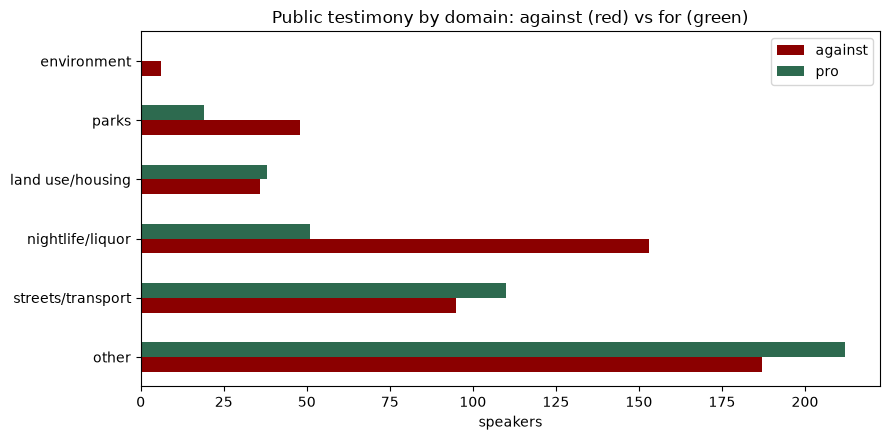

In [2]:
df = q(f"""
    SELECT {DOMAIN_CASE} AS topic_domain,
           count(*) FILTER (WHERE position='against') AS against,
           count(*) FILTER (WHERE position='for') AS pro
    FROM speakers GROUP BY 1 HAVING count(*) >= 10 ORDER BY against + pro DESC
""")
df["net"] = df.pro - df.against
ax = df.set_index("topic_domain")[["against", "pro"]].plot(
    kind="barh", figsize=(9, 4.5), color=["#8B0000", "#2d6a4f"])
ax.set_title("Public testimony by domain: against (red) vs for (green)")
ax.set_xlabel("speakers")
ax.set_ylabel("")
plt.tight_layout()
df

## 2. Who shows up

Mostly one-time speakers — residents defending their own block. But there is a
repeat cast: organized friends-of-the-park groups, advocacy orgs, and a
handful of individuals who treat the board as a beat. And "resident" is by far
the most common affiliation — this is genuinely retail politics.

In [3]:
q("""
    SELECT name, count(*) AS appearances, count(DISTINCT meeting_id) AS meetings,
           string_agg(DISTINCT position, ', ') AS positions_taken
    FROM speakers WHERE name IS NOT NULL
    GROUP BY 1 ORDER BY appearances DESC LIMIT 10
""")

,name,appearances,meetings,positions_taken
0,Kevin LaCherra,19,18,"for, neutral, against"
1,Lauren Comito,9,9,"neutral, unclear"
2,Jane Pool,7,7,"against, neutral, for"
3,Ryan Kuonen,7,7,"neutral, for"
4,Bronwyn Breitner,7,6,"for, neutral, against"
5,Sante Miceli,6,5,"neutral, against"
6,William Vega,6,6,"against, neutral"
7,Katie Naplatarski,5,5,"neutral, against"
8,Mr. Philip Leff,5,5,for
9,Katherine Thompson,5,5,"neutral, unclear, against"


In [4]:
q("""
    SELECT affiliation, count(*) AS n,
           count(*) FILTER (WHERE position='against') AS against,
           count(*) FILTER (WHERE position='for') AS pro
    FROM speakers
    WHERE affiliation IS NOT NULL AND lower(affiliation) NOT LIKE '%resident%'
    GROUP BY 1 HAVING count(*) >= 4 ORDER BY n DESC
""")

,affiliation,n,against,pro
0,Community Board 1,18,10,4
1,Community Board 1 member,7,1,0
2,Broadway Stages,6,3,0
3,Friends of Bushwick Inlet Park,5,0,2
4,Evergreen,5,3,0
5,Friends of Transmitter Park,5,5,0
6,Transportation Alternatives,4,1,3
7,Council Member Levin's Office,4,1,1
8,Brooklyn Public Library,4,0,0


## 3. The pile-ons: when a block mobilizes

Most applications draw zero speakers. A handful draw crowds. These are the
fights people organized for — and they're specific, nameable places.

In [5]:
q("""
    SELECT s.meeting_id, count(*) AS speakers_against,
           min(s.topic) AS what_they_opposed
    FROM speakers s
    WHERE s.position = 'against'
      AND (s.topic ILIKE '%applicant%' OR s.topic ILIKE '%liquor%' OR s.topic ILIKE '%sla%'
           OR s.topic ILIKE '%cannabis%')
    GROUP BY s.meeting_id,
             lower(regexp_extract(s.topic,
               '\\d+[- ]?\\d* [A-Za-z]+ (Ave|St|Street|Avenue|Place|Broadway|Blvd)', 0))
    HAVING count(*) >= 4
    ORDER BY speakers_against DESC LIMIT 12
""")

,meeting_id,speakers_against,what_they_opposed
0,cb1-2022-06-07,14,126 A Nassau Avenue Liquor License
1,cb1-2026-04-14,10,SLA application AG Acquisition 1 LLC and FIVE ...
2,cb1-2016-11-09,10,Liquor license (Beer & Wine) for Pauli Gee's
3,cb1-2017-04-19,8,POD Hotel liquor license
4,cb1-2016-12-06,8,liquor license for the POD Hotel
5,cb1-2023-06-13,8,Liquor license at 240 Broadway
6,cb1-2023-01-10,8,renewal for liquor license for 47 149 McCarren...
7,cb1-2024-10-08,7,Cannabis applicant Altitude NY LLC at 807 Manh...
8,cb1-2023-12-19,6,Cannabis Licenses within 500 feet of children'...
9,cb1-2017-11-14,4,Painting Lounge liquor license at 309 Roebling...


Spot-checks worth knowing about (verified against `source_snippet`s):

- **126A Nassau Ave (2022), 14 speakers against** — the biggest single
  mobilization in the dataset. The applicant: *Born to Lose LLC*. It opened
  anyway (as Lise & Vito). But in Nov 2024 its alteration application was
  **denied** — the community lost the war and won a battle. Full timeline below.
- **Paulie Gee's (2016), 10 against** — yes, really: ten residents opposed a
  beer-and-wine license for one of Greenpoint's most beloved pizzerias. Being
  a local institution does not exempt you from your neighbors.
- **The POD Hotel** shows up with organized opposition in 2016, 2017, *and*
  2020 — a four-year siege.

In [6]:
q("""
    SELECT m.date, l.application_type,
           coalesce(l.dba, '-') AS dba,
           coalesce(l.committee_recommendation, '') AS committee_rec,
           coalesce(l.board_action, '') AS board_action
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.address ILIKE '%126%Nassau%' OR l.applicant_name ILIKE '%born to lose%'
    ORDER BY m.date
""")

,date,application_type,dba,committee_rec,board_action
0,2022-05-10,new,TBD,,
1,2024-04-09,alteration,-,,
2,2024-09-10,alteration,-,,
3,2024-11-12,alteration,-,denial,denied
4,2025-02-11,renewal,Lise & Vito,approval,
5,2025-03-11,renewal,Lise & Vito,,
6,2025-10-21,alteration,Lise & Vito,,


## 4. The machine: why opposition usually doesn't move the needle

Two mechanics explain the gap between 3:1 opposition and ~88% approvals.

**First: the full board almost never overrules its SLA committee.** Where both
a committee recommendation and a board action are recorded, they agree ~99% of
the time. The real decision happens in committee — public-hearing testimony is
upstream input to a process that has usually already converged.

**Second: the docket is mostly renewals**, batch-approved in one motion.
Opposition concentrates on new applications; the bulk of the paperwork never
gets an individual vote at all.

In [7]:
q("""
    SELECT
      CASE WHEN lower(committee_recommendation) LIKE '%den%'
           THEN 'committee says deny' ELSE 'committee says approve' END AS committee,
      CASE WHEN lower(board_action) LIKE '%den%' THEN 'board denies'
           WHEN lower(board_action) LIKE '%approv%' OR lower(board_action) LIKE '%pass%'
           THEN 'board approves' ELSE 'board: other' END AS board,
      count(*) AS n
    FROM licenses
    WHERE committee_recommendation IS NOT NULL AND board_action IS NOT NULL
      AND (lower(committee_recommendation) LIKE '%approv%'
           OR lower(committee_recommendation) LIKE '%den%')
    GROUP BY 1, 2 ORDER BY 1, n DESC
""")

,committee,board,n
0,committee says approve,board approves,410
1,committee says approve,board: other,6
2,committee says approve,board denies,1
3,committee says deny,board denies,59
4,committee says deny,board approves,5
5,committee says deny,board: other,1


## 5. But testimony isn't theater

Where we *can* trace opposed applications to individual outcomes (address
matching within 90 days), denials cluster: the traced set runs well above the
12% baseline denial rate. The sample is small — address normalization across
"1139-1141 Manhattan Ave" vs "1139 Manhattan Avenue, Brooklyn" is the current
limit, and the geocoding phase will widen it — so treat this as directional.

The qualitative record is less ambiguous: denied applications in the minutes
are routinely denied *with the public hearing cited*, and stipulation packages
(closing hours, soundproofing, no backyard service) trace directly to
complaints raised by speakers.

In [8]:
q("""
    SELECT count(*) FILTER (WHERE lower(coalesce(board_action,'')
             || coalesce(committee_recommendation,'')) LIKE '%den%') AS denied,
           count(*) AS with_recorded_action,
           round(100.0 * count(*) FILTER (WHERE lower(coalesce(board_action,'')
             || coalesce(committee_recommendation,'')) LIKE '%den%') / count(*), 1)
             AS denial_rate_pct
    FROM licenses
    WHERE board_action IS NOT NULL OR committee_recommendation IS NOT NULL
""")

,denied,with_recorded_action,denial_rate_pct
0,154,1310,11.8


## 6. The 2025 flip

For nine years, testimony on nightlife ran negative. In 2025 it flipped:
more speakers *for* than against, for the first time in the dataset. One year
isn't a trend — but it's the first datapoint suggesting the neighborhood's
decade-long argument with its own nightlife might be winding down.

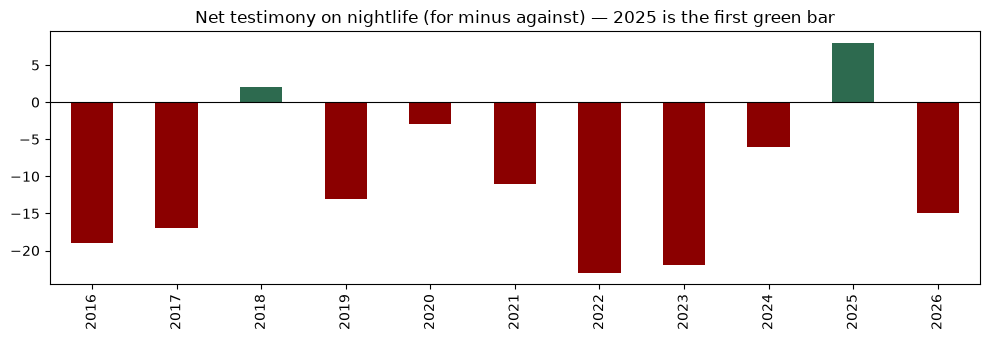

In [9]:
df = q("""
    SELECT year(m.date) AS yr,
           count(*) FILTER (WHERE s.position = 'against') AS against,
           count(*) FILTER (WHERE s.position = 'for') AS pro
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.topic ILIKE '%liquor%' OR s.topic ILIKE '%sla%' OR s.topic ILIKE '%bar%'
       OR s.topic ILIKE '%license%' OR s.topic ILIKE '%applicant%'
    GROUP BY 1 ORDER BY 1
""")
df["net_sentiment"] = df.pro - df.against
ax = df.set_index("yr")["net_sentiment"].plot(
    kind="bar", figsize=(10, 3.5),
    color=(df.net_sentiment >= 0).map({True: "#2d6a4f", False: "#8B0000"}).tolist())
ax.set_title("Net testimony on nightlife (for minus against) — 2025 is the first green bar")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("")
plt.tight_layout()

## Method notes

- `position` (for/against/neutral/unclear) is model-assigned during extraction;
  the pile-on cases above were manually verified against `source_snippet`s
  ("spoke in opposition to..."). A per-field accuracy number for `position`
  comes from the golden-set eval.
- Domain classification is keyword-based on the topic field; "other" (~47%)
  includes presentations, elections, and general district business.
- Speaker counts are testimony *records*, not unique people; the same person
  speaking at two meetings counts twice (deliberately — it measures pressure,
  not population).